In [1]:
!pip install mlflow cryptography==43.0.3 --ignore-installed blinker

  Using cached mlflow-3.14.0-py3-none-any.whl.metadata (49 kB)
  Using cached cryptography-43.0.3-cp39-abi3-manylinux_2_28_x86_64.whl.metadata (5.4 kB)
  Using cached blinker-1.9.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached cffi-2.0.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (2.6 kB)
  Using cached mlflow_skinny-3.14.0-py3-none-any.whl.metadata (50 kB)
  Using cached mlflow_tracing-3.14.0-py3-none-any.whl.metadata (19 kB)
  Using cached flask_cors-6.0.5-py3-none-any.whl.metadata (5.4 kB)
  Using cached flask-3.1.3-py3-none-any.whl.metadata (3.2 kB)
  Using cached aiohttp-3.14.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (8.3 kB)
  Using cached alembic-1.18.5-py3-none-any.whl.metadata (7.2 kB)
  Using cached docker-7.1.0-py3-none-any.whl.metadata (3.8 kB)
  Using cached graphene-3.4.3-py2.py3-none-any.whl.metadata (6.9 kB)
  Using cached gunicorn-26.0.0-py3-none-any.whl.metadata (5.4 kB)
  Using cached huey

In [1]:
'''# Reinstall scipy and scikit-learn to resolve potential version conflicts
# This ensures compatibility between numpy, scipy, and scikit-learn
!pip uninstall -y scipy scikit-learn
!pip install scipy scikit-learn'''

Found existing installation: scipy 1.18.0
Uninstalling scipy-1.18.0:
  Successfully uninstalled scipy-1.18.0
Found existing installation: scikit-learn 1.9.0
Uninstalling scikit-learn-1.9.0:
  Successfully uninstalled scikit-learn-1.9.0


In [1]:
# Store your GitHub PAT securely in Colab Secrets
# Click on the '🔑' icon on the left panel, add a new secret named 'GH_TOKEN' and paste your PAT there.
from google.colab import userdata
import os

# Get the PAT from Colab secrets
GH_TOKEN = userdata.get('GH_TOKEN')

# Set it as an environment variable (optional, but good practice if cloning private repos)
os.environ['GH_TOKEN'] = GH_TOKEN

print("GitHub Token retrieved. You can now use it for cloning private repositories.")

GitHub Token retrieved. You can now use it for cloning private repositories.


In [2]:
# Replace with your GitHub email and username
!git config --global user.email "isaac_adebayojr@gmail.com"
!git config --global user.name "isaacadebayo"

print("Git user configured.")

Git user configured.


In [3]:
# Replace 'your_username' and 'your_repository' with your actual GitHub details.
# For a public repository:
!git clone https://github.com/isaacadebayo/Agentic_projects.git

# For a private repository using PAT:
# This uses the GH_TOKEN environment variable
!git clone https://{GH_TOKEN}@github.com/isaacadebayo/Agentic_projects

# Change into your repository directory to perform Git operations
%cd Agentic_projects

print("Repository cloned. You are now in the repository directory.")

fatal: destination path 'Agentic_projects' already exists and is not an empty directory.
fatal: destination path 'Agentic_projects' already exists and is not an empty directory.
/content/Agentic_projects
Repository cloned. You are now in the repository directory.


In [4]:
# Authenticate Google Cloud for DVC to access GCS
# This will open a browser window for authentication.
# Follow the instructions to get an authorization code and paste it back.
!gcloud auth application-default login

print("Google Cloud authentication complete. You can now retry the DVC push.")

Go to the following link in your browser, and complete the sign-in prompts:

    https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=764086051850-6qr4p6gpi6hn506pt8ejuq83di341hur.apps.googleusercontent.com&redirect_uri=https%3A%2F%2Fsdk.cloud.google.com%2Fapplicationdefaultauthcode.html&scope=openid+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fuserinfo.email+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fcloud-platform+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fsqlservice.login&state=6B5BvzS4w3tvNb6OqxXGK0WAnNjwAN&prompt=consent&token_usage=remote&access_type=offline&code_challenge=nEHjrUz83PctItp3FZ2q8kImkidmhNuRgYwaF-_Az0c&code_challenge_method=S256

Once finished, enter the verification code provided in your browser: 4/0AdkVLPxfkhpQKuQJAMhHvV9yrvB6vpoi4687PbpuNiRswcKzAxp2sFdeEkKN5DJsUzqQ_Q

Credentials saved to file: [/content/.config/application_default_credentials.json]

These credentials will be used by any library that requests Application Default Credentials (ADC).
Ca

In [5]:
# Initialize DVC within the current directory (which is the cloned Git repo)
!dvc init

# Configure Google Drive as a remote storage (replace 'dvc_storage' with your desired folder name in Google Drive)
#!dvc remote add -d gdrive_remote gdrive://MyDrive/dvc_storage
!dvc remote add -d gcs_remote gs://my-agentic-chatbot-data-lake

# Create a data directory within the Git repository if it doesn't exist
!mkdir -p data

# Copy the data file into the Git repository's data directory
# This ensures the .dvc file (created by dvc add) will be within the Git repo
!cp /content/drive/MyDrive/Walmart.csv data/Walmart.csv

# Add a data file to DVC. This will create a .dvc file at data/aapl_stock_prices.csv.dvc
!dvc add data/Walmart.csv

# To commit the .dvc file to Git (requires Git setup, which is already done)
# Now git will find the .dvc file within its repository's working directory
!git add data/Walmart.csv
!git commit -m "Add Walmart.csv to DVC"

print("DVC setup complete. Your data file is now versioned with DVC and stored in Google Drive.")
print("You can push/pull changes using: !dvc push and !dvc pull")

/bin/bash: line 1: dvc: command not found
/bin/bash: line 1: dvc: command not found
cp: cannot stat '/content/drive/MyDrive/Walmart.csv': No such file or directory
/bin/bash: line 1: dvc: command not found
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
DVC setup complete. Your data file is now versioned with DVC and stored in Google Drive.
You can push/pull changes using: !dvc push and !dvc pull


In [6]:
import os
from google.colab import userdata

# Get your ngrok authtoken from Colab secrets
NGROK_AUTH_TOKEN = userdata.get('NGROK_AUTH_TOKEN')

# Set the authtoken
!ngrok authtoken {NGROK_AUTH_TOKEN}

print("ngrok authtoken configured.")

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml
ngrok authtoken configured.


In [7]:
import mlflow

mlflow.set_experiment("Walmart sales prediction")

print("MLflow experiment 'Walmart sales prediction' set.")

MLflow experiment 'Walmart sales prediction' set.


In [8]:
!pip install pyngrok

In [9]:
import subprocess, time, requests, os, re
from pyngrok import ngrok
from google.colab import userdata

# ── 1. Kill everything ────────────────────────────────────────────
subprocess.run("pkill -f 'mlflow server'", shell=True)
subprocess.run("pkill -f proxy.py", shell=True)
subprocess.run("pkill -f cloudflared", shell=True)
time.sleep(3)

# ── 2. Start MLflow ───────────────────────────────────────────────
env = os.environ.copy()
env["GUNICORN_CMD_ARGS"] = "--forwarded-allow-ips='*'"

subprocess.Popen(
    ["mlflow", "server",
     "--backend-store-uri", "sqlite:////content/Agentic_projects/mlflow.db",
     "--serve-artifacts",
     "--host", "0.0.0.0",
     "--port", "5000",
     "--cors-allowed-origins", "https://ia-mlflow-dashboard.ngrok.app"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.STDOUT,
    cwd="/content/Agentic_projects",
    env=env
)

print("Waiting for MLflow...")
for i in range(30):
    try:
        r = requests.get("http://localhost:5000/health", timeout=3)
        if r.status_code == 200:
            print(f"MLflow ready")
            break
    except Exception:
        pass
    time.sleep(2)

# ── 3. Write proxy (rewrites Host header to localhost:5000) ────────
proxy_code = """
import http.server
import http.client
import urllib.parse

class Proxy(http.server.BaseHTTPRequestHandler):
    def _proxy(self, body=None):
        parsed = urllib.parse.urlparse(f"http://localhost:5000{self.path}")

        conn = http.client.HTTPConnection("localhost", 5000, timeout=30)

        headers = dict(self.headers)
        headers["Host"] = "localhost:5000"
        headers["X-Forwarded-Host"] = "localhost:5000"
        headers["X-Forwarded-Proto"] = "http"
        headers.pop("Transfer-Encoding", None)
        headers.pop("transfer-encoding", None)

        try:
            conn.request(self.command, parsed.path + (f"?{parsed.query}" if parsed.query else ""), body=body, headers=headers)
            resp = conn.getresponse()

            self.send_response(resp.status)

            for k, v in resp.getheaders():
                if k.lower() not in ("transfer-encoding", "connection", "keep-alive"):
                    self.send_header(k, v)
            self.send_header("Access-Control-Allow-Origin", "*")
            self.send_header("Access-Control-Allow-Headers", "*")
            self.end_headers()

            # Stream response in chunks — fixes chart data loading
            while True:
                chunk = resp.read(8192)
                if not chunk:
                    break
                self.wfile.write(chunk)
            self.wfile.flush()

        except Exception as e:
            self.send_response(502)
            self.end_headers()
            self.wfile.write(str(e).encode())
        finally:
            conn.close()

    def do_GET(self):     self._proxy()
    def do_POST(self):
        length = int(self.headers.get("Content-Length", 0))
        self._proxy(self.rfile.read(length) if length else None)
    def do_PUT(self):
        length = int(self.headers.get("Content-Length", 0))
        self._proxy(self.rfile.read(length) if length else None)
    def do_DELETE(self):  self._proxy()
    def do_OPTIONS(self):
        self.send_response(200)
        self.send_header("Access-Control-Allow-Origin", "*")
        self.send_header("Access-Control-Allow-Methods", "GET, POST, PUT, DELETE, OPTIONS")
        self.send_header("Access-Control-Allow-Headers", "*")
        self.end_headers()
    def log_message(self, *args): pass

server = http.server.HTTPServer(('0.0.0.0', 5001), Proxy)
server.serve_forever()
"""

with open("proxy.py", "w") as f:
    f.write(proxy_code)

subprocess.Popen(["python", "proxy.py"],
                 stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
print("Proxy started on port 5001")
time.sleep(3)

# ── 4. Connect ngrok to proxy on port 5001 ────────────────────────
ngrok.set_auth_token(userdata.get('NGROK_AUTH_TOKEN'))

# Replace with your custom domain
public_url = ngrok.connect(5001, domain="ia-mlflow-dashboard.ngrok.app")
print(f"\nMLflow UI: {public_url}\n")

Waiting for MLflow...
MLflow ready
Proxy started on port 5001

MLflow UI: NgrokTunnel: "https://ia-mlflow-dashboard.ngrok.app" -> "http://localhost:5001"



In [10]:
# Reinstall scipy and scikit-learn to resolve potential version conflicts
# This ensures compatibility between numpy, scipy, and scikit-learn
!pip uninstall -y scipy scikit-learn
!pip install scipy scikit-learn

Found existing installation: scipy 1.18.0
Uninstalling scipy-1.18.0:
  Successfully uninstalled scipy-1.18.0
Found existing installation: scikit-learn 1.9.0
Uninstalling scikit-learn-1.9.0:
  Successfully uninstalled scikit-learn-1.9.0
  Using cached scipy-1.18.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached scikit_learn-1.9.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
Using cached scipy-1.18.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (35.3 MB)
Using cached scikit_learn-1.9.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (9.1 MB)


# DONT RESTART SESSION

In [11]:
import mlflow
import os
import json
import mlflow.sklearn # Import mlflow.tensorflow for Keras autologging

# Set the MLflow tracking URI to connect to the server started by ngrok
# The ngrok setup usually exposes localhost:5000
mlflow.set_tracking_uri("http://localhost:5000")

# Set an experiment name for better organization in the MLflow UI
mlflow.set_experiment("Walmart sales prediction")

# Enable autologging for TensorFlow/Keras models
mlflow.sklearn.autolog()

print("MLflow sklearn tracking setup complete.")

MLflow sklearn tracking setup complete.


In [12]:
!pip install tensorflow

In [13]:
import mlflow
import mlflow.langchain
import mlflow.openai
import os
import json
import mlflow.tensorflow # Import mlflow.tensorflow for Keras autologging

# Set the MLflow tracking URI to connect to the server started by ngrok
# The ngrok setup usually exposes localhost:5000
mlflow.set_tracking_uri("http://localhost:5000")

# Set an experiment name for better organization in the MLflow UI
mlflow.set_experiment("Walmart sales prediction")

# Enable autologging for TensorFlow/Keras models
mlflow.tensorflow.autolog()

print("MLflow tracking setup complete.")

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


MLflow tracking setup complete.


In [ ]:
# Reinstall scipy and scikit-learn to resolve potential version conflicts
# This ensures compatibility between numpy, scipy, and scikit-learn
'''!pip uninstall -y scipy scikit-learn
!pip install scipy scikit-learn'''

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive

In [15]:
drive.mount('/content/drive', force_remount=True)
data = pd.read_csv('/content/drive/MyDrive/Walmart.csv')

Mounted at /content/drive


In [16]:
data['Date'] = pd.to_datetime(data['Date'], format='%d-%m-%Y')
data = data.sort_values('Date').reset_index(drop=True)
data['Date'] = data['Date'].dt.strftime('%d-%m-%Y')  # keep string format for downstream EDA cells

In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [18]:
data.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,10,05-02-2010,2193048.75,0,54.34,2.962,126.442065,9.765
2,37,05-02-2010,536006.73,0,45.97,2.572,209.852966,8.554
3,17,05-02-2010,789036.02,0,23.11,2.666,126.442065,6.548
4,30,05-02-2010,465108.52,0,39.05,2.572,210.752605,8.324


In [19]:
data.shape

(6435, 8)

In [20]:
data.isnull().sum()

,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


### Feature Engineering

In [21]:
data['CPI_per_Fuel' ]= data['CPI'] / data['Fuel_Price']
data['Holiday_x_Temp'] = data['Holiday_Flag'] * data['Temperature']
data['CPI_per_Unemployment' ]= data['Unemployment'] / data['CPI']
#data['Affordability_per_unemployment' ]= data['Unemployment'] / data['Weekly_Sales']

When engineering a feature if you use the target variable you introduce a data leak.

In [22]:
data

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,CPI_per_Fuel,Holiday_x_Temp,CPI_per_Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106,82.074789,0.0,0.038400
1,10,05-02-2010,2193048.75,0,54.34,2.962,126.442065,9.765,42.688070,0.0,0.077229
2,37,05-02-2010,536006.73,0,45.97,2.572,209.852966,8.554,81.591355,0.0,0.040762
3,17,05-02-2010,789036.02,0,23.11,2.666,126.442065,6.548,47.427631,0.0,0.051787
4,30,05-02-2010,465108.52,0,39.05,2.572,210.752605,8.324,81.941137,0.0,0.039497
...,...,...,...,...,...,...,...,...,...,...,...
6430,25,26-10-2012,688940.94,0,56.69,3.882,216.151590,7.293,55.680471,0.0,0.033740
6431,5,26-10-2012,319550.77,0,71.70,3.506,224.037814,5.422,63.901259,0.0,0.024201
6432,40,26-10-2012,921264.52,0,49.65,3.917,138.728161,4.145,35.416942,0.0,0.029879
6433,18,26-10-2012,1127516.25,0,56.09,3.917,138.728161,8.243,35.416942,0.0,0.059418


For Affordability per sale, weekly sale goes up as CPI goes up per month section due to metric tracking inflation and purchasing power of currency. Therefore Affordability per sale goes down

### EDA

<function matplotlib.pyplot.show(close=None, block=None)>

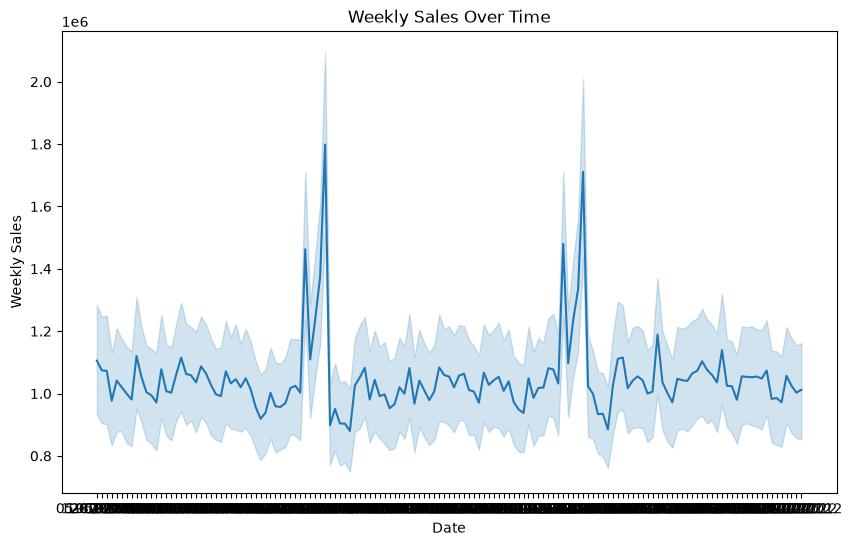

In [23]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='Date', y='Weekly_Sales', data=data)
plt.title('Weekly Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

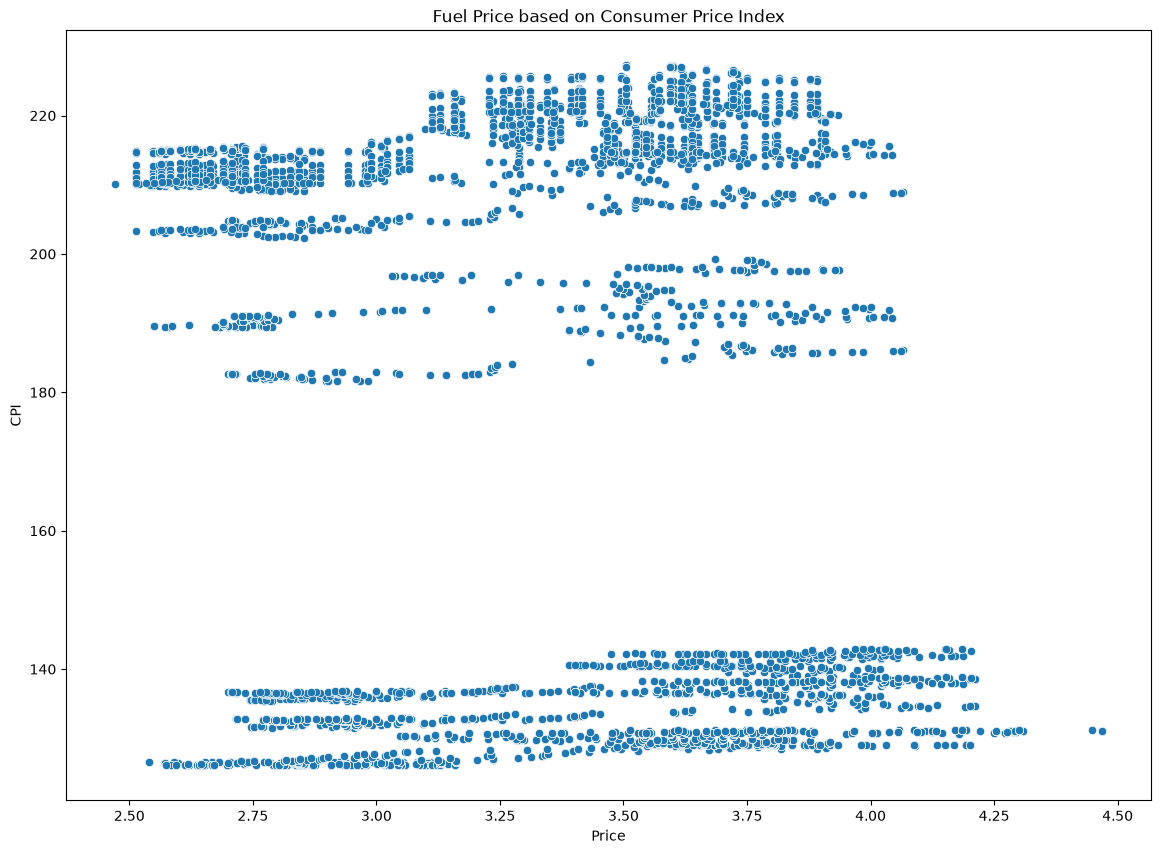

In [24]:
plt.figure(figsize=(14, 10))
sns.scatterplot(x='Fuel_Price', y='CPI', data=data)
plt.title('Fuel Price based on Consumer Price Index')
plt.xlabel('Price')
plt.ylabel('CPI')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

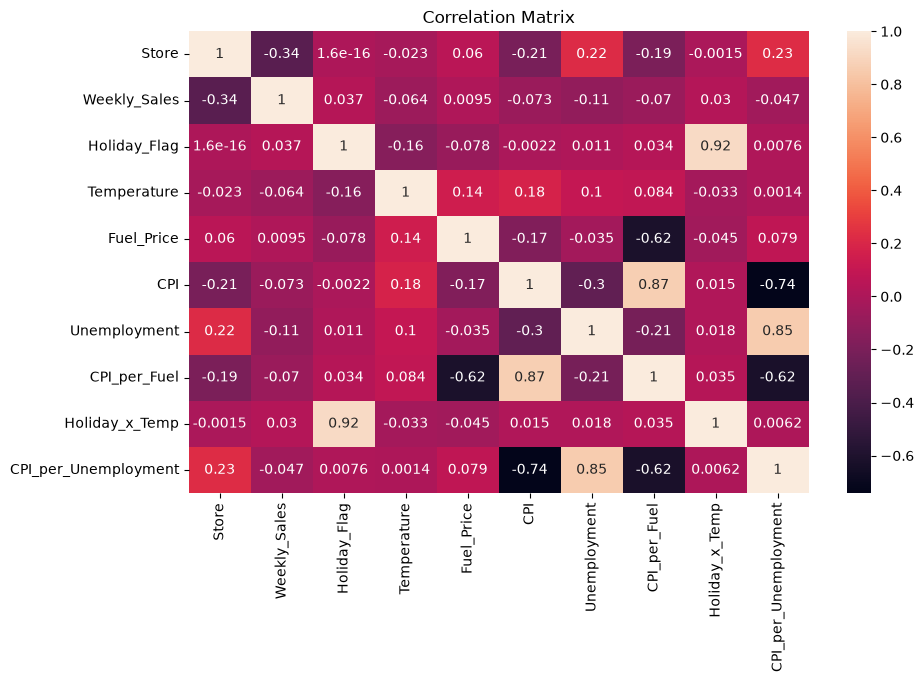

In [25]:
data2 = data.copy()
data3 = data2.drop('Date', axis=1)
#corr = data.select_dtypes(exclude='Date').corr()

plt.figure(figsize=(10,6))
sns.heatmap(data3.corr(), annot=True)
plt.title('Correlation Matrix')
plt.show

#data3.info()

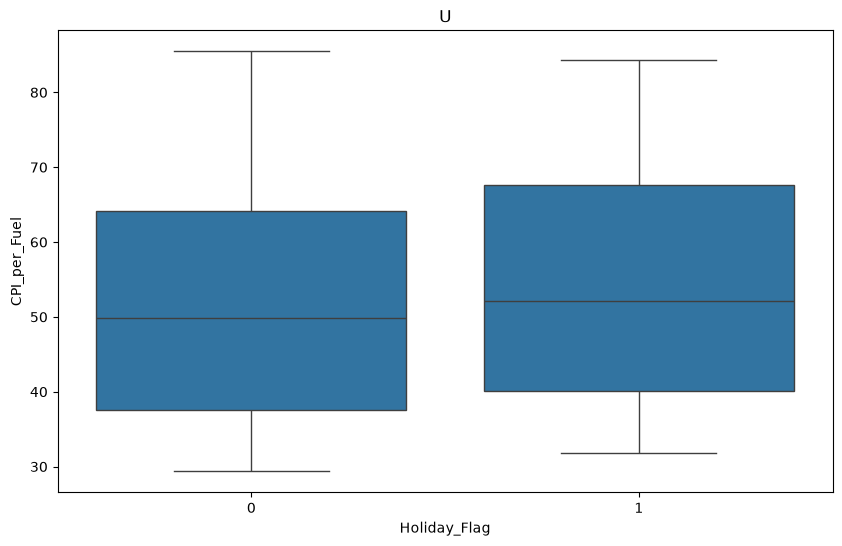

In [26]:
plt.figure(figsize=(10,6))
sns.boxplot(y='CPI_per_Fuel', x='Holiday_Flag', data=data)
plt.xlabel('Holiday_Flag')
plt.ylabel('CPI_per_Fuel')
plt.title('U')
plt.show()

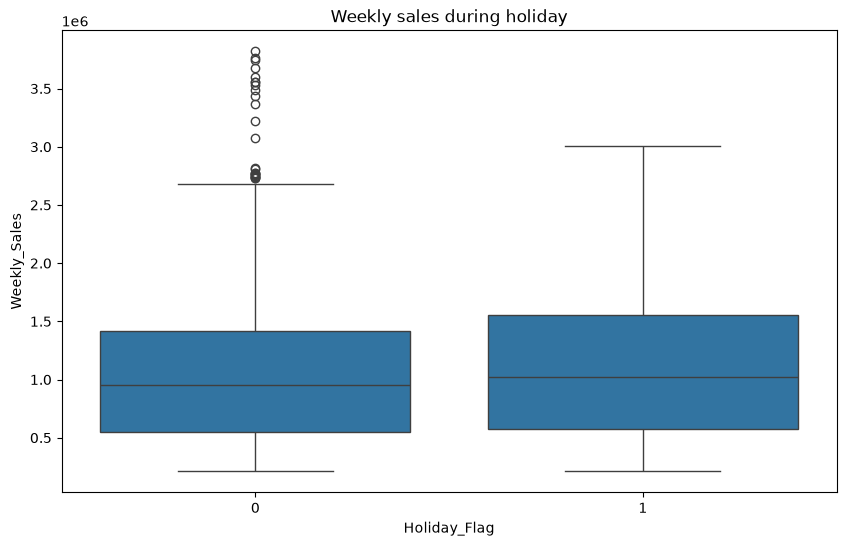

In [27]:
plt.figure(figsize=(10,6))
sns.boxplot(y='Weekly_Sales', x='Holiday_Flag', data=data)
plt.ylabel('Weekly_Sales')
plt.xlabel('Holiday_Flag')
plt.title('Weekly sales during holiday')
plt.show()

### Dropping target variable

In [28]:
X_data = data3.drop(columns=['Weekly_Sales'])
y = data3['Weekly_Sales']

if you scale before dropping you introduce data leakage

### Split features to X_train and X_test

In [29]:
from sklearn.model_selection import train_test_split

# Split data for general use. These X_train, X_test will be further processed for LSTM.
# y_train_for_sklearn and y_test_for_sklearn will be used specifically for sklearn models
# to avoid sample size inconsistencies caused by LSTM's windowing.
X_train, X_test, y_train_for_sklearn, y_test_for_sklearn = train_test_split(X_data, y,
                                                    test_size=0.2, shuffle=False)


# Scaling

Scale only X_train

,count,mean,std,min,25%,50%,75%,max
Store,5148.0,-2.415404e-17,1.000097,-1.694017,-0.846971,0.000075,0.847120,1.694166
Holiday_Flag,5148.0,8.281384e-18,1.000097,-0.292214,-0.292214,-0.292214,-0.292214,3.422150
Temperature,5148.0,8.833476e-17,1.000097,-3.192458,-0.722797,0.039924,0.750484,2.247184
Fuel_Price,5148.0,7.066781e-16,1.000097,-1.765165,-0.948155,-0.055040,0.858220,2.313169
CPI,5148.0,2.208369e-17,1.000097,-1.143210,-0.998726,0.308764,1.050060,1.406000
Unemployment,5148.0,2.760461e-16,1.000097,-2.159499,-0.525885,-0.085001,0.236610,3.265291
CPI_per_Fuel,5148.0,2.208369e-16,1.000097,-1.501619,-0.897417,-0.208513,0.857239,2.072446
Holiday_x_Temp,5148.0,5.520923e-18,1.000097,-0.270478,-0.270478,-0.270478,-0.270478,6.746804
CPI_per_Unemployment,5148.0,-1.325021e-16,1.000097,-1.329898,-0.762189,-0.264523,0.515386,3.076218


,Store,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,CPI_per_Fuel,Holiday_x_Temp,CPI_per_Unemployment
Store,1.000000,0.000022,-0.024175,0.055224,-0.209588,0.225030,-0.193669,-0.001535,0.226240
Holiday_Flag,0.000022,1.000000,-0.167625,-0.066369,0.001452,-0.002106,0.029567,0.925616,-0.002052
Temperature,-0.024175,-0.167625,1.000000,0.054796,0.172197,0.177042,0.126435,-0.050621,0.047744
Fuel_Price,0.055224,-0.066369,0.054796,1.000000,-0.171823,0.014071,-0.610383,-0.053708,0.110239
CPI,-0.209588,0.001452,0.172197,-0.171823,1.000000,-0.300201,0.873265,0.018984,-0.744616
Unemployment,0.225030,-0.002106,0.177042,0.014071,-0.300201,1.000000,-0.238711,0.016705,0.849867
CPI_per_Fuel,-0.193669,0.029567,0.126435,-0.610383,0.873265,-0.238711,1.000000,0.040840,-0.640849
Holiday_x_Temp,-0.001535,0.925616,-0.050621,-0.053708,0.018984,0.016705,0.040840,1.000000,0.003573
CPI_per_Unemployment,0.226240,-0.002052,0.047744,0.110239,-0.744616,0.849867,-0.640849,0.003573,1.000000


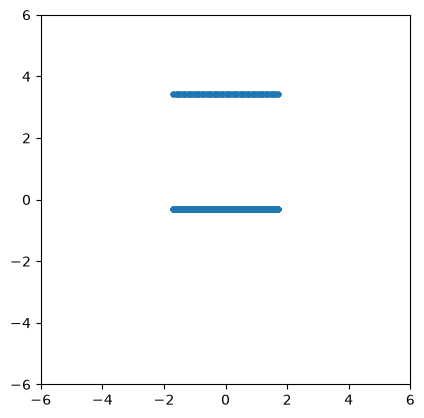

In [30]:

from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

df_X1_data = pd.DataFrame(X_train_scaled, columns=X_train.columns)
display(df_X1_data.describe().T)
display(df_X1_data.corr())

plt.plot( X_train_scaled[:,0], X_train_scaled[:,1], '.' )
plt.xlim(-6,6)
plt.ylim(-6,6)
plt.gca().set_aspect('equal')

### Principal Component Analysis

PCA on X_train

In [31]:
from sklearn.decomposition import PCA

pca = PCA(n_components=9)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

2026/07/04 16:40:28 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '9375433c0a9249a793b1b67c150fef13', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/07/04 16:40:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/04 16:40:28 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/07/04 16:40:31 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model traini

🏃 View run victorious-lamb-977 at: http://localhost:5000/#/experiments/1/runs/9375433c0a9249a793b1b67c150fef13
🧪 View experiment at: http://localhost:5000/#/experiments/1


## Models

In [32]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

models = [
    LinearRegression(),
    KNeighborsRegressor(n_neighbors=1, weights='uniform'),
    KNeighborsRegressor(n_neighbors=10, weights='uniform'),
    KNeighborsRegressor(n_neighbors=100, weights='uniform'),
    DecisionTreeRegressor(max_depth=2),
    DecisionTreeRegressor(max_depth=5),
    DecisionTreeRegressor(max_depth=10),
    RandomForestRegressor(n_estimators=10, max_depth=5),
    RandomForestRegressor(n_estimators=100, max_depth=10),
    GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=2),
]

In [33]:
from sklearn.model_selection import cross_val_score, KFold

kf = KFold(n_splits=5, shuffle=False)

X_train.columns = X_train.columns.astype(str) # Convert column names to strings

for m in models:
    print(m)

    cv_scores = -cross_val_score(m, X_train, y_train_for_sklearn, cv=kf, scoring='neg_mean_absolute_percentage_error')
    cv_scores = pd.DataFrame(cv_scores)
    display(cv_scores.describe().T)

    print()
# end

LinearRegression()


,count,mean,std,min,25%,50%,75%,max
0,5.0,0.580274,0.061887,0.506593,0.539715,0.568833,0.632691,0.653536



KNeighborsRegressor(n_neighbors=1)


,count,mean,std,min,25%,50%,75%,max
0,5.0,0.292229,0.111103,0.178127,0.186824,0.292666,0.376771,0.426759



KNeighborsRegressor(n_neighbors=10)


...

,count,mean,std,min,25%,50%,75%,max
0,5.0,0.276174,0.036126,0.2278,0.270878,0.27615,0.276464,0.32958



RandomForestRegressor(max_depth=10)


,count,mean,std,min,25%,50%,75%,max
0,5.0,0.152674,0.054389,0.068598,0.147169,0.147191,0.190589,0.209821



GradientBoostingRegressor(max_depth=2)


,count,mean,std,min,25%,50%,75%,max
0,5.0,0.334936,0.014207,0.320179,0.322213,0.333328,0.34844,0.350517


#Grid Search CV

In [34]:
from sklearn.model_selection import GridSearchCV

# Define models and their parameter grids
param_grids = {
    "KNeighborsRegressor": (
        KNeighborsRegressor(),
        {
            "n_neighbors": [1, 5, 10, 20, 50],
            "weights": ["uniform", "distance"]
        }
    ),

    "RandomForestRegressor": (
        RandomForestRegressor(),
        {
            "n_estimators": [10, 50, 100],
            "max_depth": [3, 5, 10],
            "min_samples_split": [2, 5, 10],
            'min_samples_leaf': [1, 2, 5, 10]
        }
    ),

    "GradientBoostingRegressor": (
        GradientBoostingRegressor(),
        {
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.01, 0.1, 0.2],
            "max_depth": [2, 3, 5],
            'min_samples_leaf': [1, 2, 5, 10]
        }
    ),

    "DecisionTreeRegressor": (
        DecisionTreeRegressor(),
        {
            "max_depth": [2, 3, 5, 10],
            "min_samples_split": [2, 5, 10],
            'min_samples_leaf': [1, 2, 5, 10]
        }
    ),

    "LinearRegression": (
        LinearRegression(),
        {
            "fit_intercept": [True, False],
        }
    ),

  }

# Define cross-validation strategy
kf = KFold(n_splits=5, shuffle=True)

X_train.columns = X_train.columns.astype(str) # Convert column names to strings

# Store results
results = []

# Perform GridSearchCV for each model
for name, (model, param_grid) in param_grids.items():
    print(f"Performing GridSearchCV for {name}...")

    grid_search = GridSearchCV(model, param_grid, cv=kf, scoring="neg_mean_absolute_percentage_error", n_jobs=-1)
    grid_search.fit(X_train_pca, y_train_for_sklearn)

    best_params = grid_search.best_params_
    best_score = grid_search.best_score_

    results.append({"Model": name, "Best Score": best_score, "Best Params": best_params})
# end

results

2026/07/04 16:40:39 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '6b415d94e3cd412fb8274f8b6d5c4aab', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/07/04 16:40:39 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'


Performing GridSearchCV for KNeighborsRegressor...


2026/07/04 16:40:41 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/04 16:40:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/04 16:40:45 INFO mlflow.sklearn.utils: Logging the 5 best runs, 5 runs will be omitted.
2026/07/04 16:40:45 WARNING mlflow.sklearn: Encountered exception during creation of child runs for pa

🏃 View run clean-rat-511 at: http://localhost:5000/#/experiments/1/runs/6b415d94e3cd412fb8274f8b6d5c4aab
🧪 View experiment at: http://localhost:5000/#/experiments/1
Performing GridSearchCV for RandomForestRegressor...


2026/07/04 16:40:56 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/04 16:40:58 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/04 16:41:00 INFO mlflow.sklearn.utils: Logging the 5 best runs, 103 runs will be omitted.
2026/07/04 16:41:00 WARNING mlflow.sklearn: Encountered exception during creation of child runs for 

...

2026/07/04 16:41:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/04 16:41:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/04 16:41:33 INFO mlflow.sklearn.utils: Logging the 5 best runs, 43 runs will be omitted.
2026/07/04 16:41:33 WARNING mlflow.sklearn: Encountered exception during creation of child runs for p

🏃 View run unleashed-horse-280 at: http://localhost:5000/#/experiments/1/runs/9240040f3fd24afa942cf502c450d95d
🧪 View experiment at: http://localhost:5000/#/experiments/1
Performing GridSearchCV for LinearRegression...


2026/07/04 16:41:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/04 16:41:37 INFO mlflow.sklearn.utils: Logging the 5 best runs, no runs will be omitted.
2026/07/04 16:41:37 WARNING mlflow.sklearn: Encountered exception during creation of child runs for parameter search. Child runs may be missing. Exception: 'NoneType' object has no attribute '_to_mlflow_entity'


🏃 View run luminous-goose-266 at: http://localhost:5000/#/experiments/1/runs/4676f8a7775744e9a0e752f20200d648
🧪 View experiment at: http://localhost:5000/#/experiments/1


[{'Model': 'KNeighborsRegressor',
  'Best Score': np.float64(-0.23956124588953479),
  'Best Params': {'n_neighbors': 1, 'weights': 'uniform'}},
 {'Model': 'RandomForestRegressor',
  'Best Score': np.float64(-0.25368518692620823),
  'Best Params': {'max_depth': 10,
   'min_samples_leaf': 1,
   'min_samples_split': 2,
   'n_estimators': 100}},
 {'Model': 'GradientBoostingRegressor',
  'Best Score': np.float64(-0.25093285660858833),
  'Best Params': {'learning_rate': 0.2,
   'max_depth': 5,
   'min_samples_leaf': 5,
   'n_estimators': 200}},
 {'Model': 'DecisionTreeRegressor',
  'Best Score': np.float64(-0.2700058888889173),
  'Best Params': {'max_depth': 10,
   'min_samples_leaf': 1,
   'min_samples_split': 2}},
 {'Model': 'LinearRegression',
  'Best Score': np.float64(-0.5734038368971068),
  'Best Params': {'fit_intercept': True}}]

## Parismony

In [35]:
# Fit a Random Forest model
rf = RandomForestRegressor(n_estimators=1000)
rf.fit(X_train, y_train_for_sklearn)

# Get feature importances
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
importances = importances[:10]

features_rf = importances.index

X_pars = X_train[ features_rf ]
importances

2026/07/04 16:41:37 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '03a2ae38ff3e4870862247f65aa644d3', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/07/04 16:41:37 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/lib/python3.12/dist-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https:/

🏃 View run valuable-snail-277 at: http://localhost:5000/#/experiments/1/runs/03a2ae38ff3e4870862247f65aa644d3
🧪 View experiment at: http://localhost:5000/#/experiments/1


,0
Store,0.524202
CPI_per_Unemployment,0.174748
CPI,0.143758
Unemployment,0.057113
CPI_per_Fuel,0.055937
Temperature,0.023891
Fuel_Price,0.011790
Holiday_x_Temp,0.007796
Holiday_Flag,0.000764


## VIF

In [36]:
!pip install statsmodels

In [37]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

X_pars_with_const = sm.add_constant(X_pars)

vif = pd.Series(
    [variance_inflation_factor(X_pars_with_const.values, i) for i in range(X_pars_with_const.shape[1])],
    index=X_pars_with_const.columns
).sort_values(ascending=False)

vif[:10]

,0
const,1303.156919
CPI_per_Unemployment,86.348953
CPI_per_Fuel,55.934920
CPI,48.984687
Unemployment,42.601474
Fuel_Price,13.592439
Holiday_Flag,7.791088
Holiday_x_Temp,7.584561
Temperature,1.279165
Store,1.253389


In [38]:
# Copy dataset to avoid modifying the original
X_vif = X_pars.copy()
while True:
  X_vif_with_const = sm.add_constant(X_vif)

  # Compute VIF for all features
  vif_series = pd.Series(
  [variance_inflation_factor(X_vif_with_const.values, i) for i in range(X_vif_with_const.shape[1])],
  index=X_vif_with_const.columns
    )
  #Exclude constant term
  vif_series = vif_series.drop('const', errors='ignore')
  highest_vif_feature = vif_series.idxmax()
  # Break the loop if all features have VIF ≤ 10
  if vif_series.loc[highest_vif_feature] <= 10:  # Checking the first feature after 'const'
    break

  # Drop the feature with the highest VIF
  X_vif = X_vif.drop(columns=[highest_vif_feature])

  print(f"Dropped: {highest_vif_feature} (VIF={vif_series.loc[highest_vif_feature]:.2f})")
  # end


vif_series[:25]

Dropped: CPI_per_Unemployment (VIF=86.35)
Dropped: CPI_per_Fuel (VIF=53.31)


,0
Store,1.080621
CPI,1.235118
Unemployment,1.212996
Temperature,1.228510
Fuel_Price,1.046166
Holiday_x_Temp,7.576886
Holiday_Flag,7.784367


### Training a Linear Regression Model with VIF-Selected Features

In [39]:
from sklearn.model_selection import GridSearchCV

# Define models and their parameter grids
param_grids = {
    "KNeighborsRegressor": (
        KNeighborsRegressor(),
        {
            "n_neighbors": [1, 5, 10, 20, 50],
            "weights": ["uniform", "distance"]
        }
    ),

    "RandomForestRegressor": (
        RandomForestRegressor(),
        {
            "n_estimators": [10, 50, 100],
            "max_depth": [3, 5, 10],
            "min_samples_split": [2, 5, 10],
            'min_samples_leaf': [1, 2, 5, 10]
        }
    ),

    "GradientBoostingRegressor": (
        GradientBoostingRegressor(),
        {
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.01, 0.1, 0.2],
            "max_depth": [2, 3, 5],
            "subsample": [0.8, 1.0],
            'min_samples_leaf': [1, 2, 5, 10]
        }
    ),

    "DecisionTreeRegressor": (
        DecisionTreeRegressor(),
        {
            "max_depth": [2, 3, 5, 10],
            "min_samples_split": [2, 5, 10],
            'min_samples_leaf': [1, 2, 5, 10]
        }
    ),

    "LinearRegression": (
        LinearRegression(),
        {
            "fit_intercept": [True, False],
        }
    ),

  }

# Define cross-validation strategy
kf = KFold(n_splits=5, shuffle=False)

X_train.columns = X_train.columns.astype(str) # Convert column names to strings

# Store results
results = []

# Perform GridSearchCV for each model
for name, (model, param_grid) in param_grids.items():
    print(f"Performing GridSearchCV for {name}...")

    grid_search = GridSearchCV(model, param_grid, cv=kf, scoring="neg_mean_absolute_percentage_error", n_jobs=-1)
    # Fit on the original scaled features, not PCA-transformed data, as requested,
    # and use y_train_for_sklearn for consistent sample size.
    grid_search.fit(X_train_scaled, y_train_for_sklearn)

    best_params = grid_search.best_params_
    best_score = grid_search.best_score_

    results.append({"Model": name, "Best Score": best_score, "Best Params": best_params})
# end

results

2026/07/04 16:42:00 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'd9f64afe18ca477d8892c2b8cc1dc6ef', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/07/04 16:42:00 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'


Performing GridSearchCV for KNeighborsRegressor...


2026/07/04 16:42:00 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/04 16:42:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/04 16:42:04 INFO mlflow.sklearn.utils: Logging the 5 best runs, 5 runs will be omitted.
2026/07/04 16:42:04 WARNING mlflow.sklearn: Encountered exception during creation of child runs for pa

🏃 View run classy-eel-972 at: http://localhost:5000/#/experiments/1/runs/d9f64afe18ca477d8892c2b8cc1dc6ef
🧪 View experiment at: http://localhost:5000/#/experiments/1
Performing GridSearchCV for RandomForestRegressor...


2026/07/04 16:42:11 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/04 16:42:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/04 16:42:15 INFO mlflow.sklearn.utils: Logging the 5 best runs, 103 runs will be omitted.
2026/07/04 16:42:15 WARNING mlflow.sklearn: Encountered exception during creation of child runs for 

...

2026/07/04 16:42:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/04 16:42:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/04 16:42:47 INFO mlflow.sklearn.utils: Logging the 5 best runs, 43 runs will be omitted.
2026/07/04 16:42:47 WARNING mlflow.sklearn: Encountered exception during creation of child runs for p

🏃 View run dapper-shoat-936 at: http://localhost:5000/#/experiments/1/runs/cb5344a25e1d48678af7d017ab9967ea
🧪 View experiment at: http://localhost:5000/#/experiments/1
Performing GridSearchCV for LinearRegression...


2026/07/04 16:42:49 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/04 16:42:51 INFO mlflow.sklearn.utils: Logging the 5 best runs, no runs will be omitted.
2026/07/04 16:42:51 WARNING mlflow.sklearn: Encountered exception during creation of child runs for parameter search. Child runs may be missing. Exception: 'NoneType' object has no attribute '_to_mlflow_entity'


🏃 View run delicate-sow-659 at: http://localhost:5000/#/experiments/1/runs/211bc0130809403b8410b38be40498a9
🧪 View experiment at: http://localhost:5000/#/experiments/1


[{'Model': 'KNeighborsRegressor',
  'Best Score': np.float64(-0.3125396042730067),
  'Best Params': {'n_neighbors': 1, 'weights': 'uniform'}},
 {'Model': 'RandomForestRegressor',
  'Best Score': np.float64(-0.14059709053056074),
  'Best Params': {'max_depth': 10,
   'min_samples_leaf': 10,
   'min_samples_split': 10,
   'n_estimators': 10}},
 {'Model': 'GradientBoostingRegressor',
  'Best Score': np.float64(-0.154936401169046),
  'Best Params': {'learning_rate': 0.2,
   'max_depth': 5,
   'min_samples_leaf': 5,
   'n_estimators': 100,
   'subsample': 0.8}},
 {'Model': 'DecisionTreeRegressor',
  'Best Score': np.float64(-0.16823977295788817),
  'Best Params': {'max_depth': 10,
   'min_samples_leaf': 10,
   'min_samples_split': 10}},
 {'Model': 'LinearRegression',
  'Best Score': np.float64(-0.5802737261381246),
  'Best Params': {'fit_intercept': True}}]

In [40]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler # Import StandardScaler for VIF-specific scaling

# Select the VIF-selected features from the original X_train and X_test DataFrames
X_train_vif_selected = X_train[X_vif.columns]
X_test_vif_selected = X_test[X_vif.columns]

# Create a NEW scaler specifically for the VIF-selected features
vif_scaler = StandardScaler()
X_train_vif_scaled = vif_scaler.fit_transform(X_train_vif_selected)
X_test_vif_scaled = vif_scaler.transform(X_test_vif_selected)

# Train a Linear Regression model using the VIF-selected and scaled features
lreg_vif = LinearRegression()
lreg_vif.fit(X_train_vif_scaled, y_train_for_sklearn)

# Train a RF Regression model using the VIF-selected and scaled features
RFreg_vif = RandomForestRegressor()
RFreg_vif.fit(X_train_vif_scaled, y_train_for_sklearn)

# Train a GB Regression model using the VIF-selected and scaled features
GBreg_vif = GradientBoostingRegressor()
GBreg_vif.fit(X_train_vif_scaled, y_train_for_sklearn)

# Make predictions on the scaled VIF-selected training and test sets for Linear Regression
y_train_pred_lreg_vif = lreg_vif.predict(X_train_vif_scaled)
y_test_pred_lreg_vif = lreg_vif.predict(X_test_vif_scaled)

# Make predictions on the scaled VIF-selected training and test sets for Random Forest Regression
y_train_pred_rf_vif = RFreg_vif.predict(X_train_vif_scaled)
y_test_pred_rf_vif = RFreg_vif.predict(X_test_vif_scaled)

# Make predictions on the scaled VIF-selected training and test sets for Gradient Boosting Regression
y_train_pred_gb_vif = GBreg_vif.predict(X_train_vif_scaled)
y_test_pred_gb_vif = GBreg_vif.predict(X_test_vif_scaled)

# Calculate and print R-squared values for the model with VIF-selected features
print(f"RF Regression (VIF-selected features) - Train R²:  {r2_score(y_train_for_sklearn, y_train_pred_rf_vif):.4f}")
print(f"RF Regression (VIF-selected features) - Test  R²:  {r2_score(y_test_for_sklearn, y_test_pred_rf_vif):.4f}")

print(f"GB Regression (VIF-selected features) - Train R²:  {r2_score(y_train_for_sklearn, y_train_pred_gb_vif):.4f}")
print(f"GB Regression (VIF-selected features) - Test  R²:  {r2_score(y_test_for_sklearn, y_test_pred_gb_vif):.4f}")

print(f"Linear Regression (VIF-selected features) - Train R²:  {r2_score(y_train_for_sklearn, y_train_pred_lreg_vif):.4f}")
print(f"Linear Regression (VIF-selected features) - Test  R²:  {r2_score(y_test_for_sklearn, y_test_pred_lreg_vif):.4f}")

2026/07/04 16:42:51 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'c402d6641b1e462988da8fb734882e72', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/07/04 16:42:51 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/07/04 16:42:51 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/04 16:42:53 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'a3a78caadf5c47dca15d88d889562a96', which will track hyperparameters, performance me

🏃 View run dapper-trout-473 at: http://localhost:5000/#/experiments/1/runs/c402d6641b1e462988da8fb734882e72
🧪 View experiment at: http://localhost:5000/#/experiments/1


2026/07/04 16:42:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/04 16:42:57 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '110f36a36cde4c7ab8b6da07591654b3', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/07/04 16:42:57 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'


🏃 View run gregarious-yak-459 at: http://localhost:5000/#/experiments/1/runs/a3a78caadf5c47dca15d88d889562a96
🧪 View experiment at: http://localhost:5000/#/experiments/1


2026/07/04 16:42:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run aged-owl-358 at: http://localhost:5000/#/experiments/1/runs/110f36a36cde4c7ab8b6da07591654b3
🧪 View experiment at: http://localhost:5000/#/experiments/1
RF Regression (VIF-selected features) - Train R²:  0.9903
RF Regression (VIF-selected features) - Test  R²:  0.8765
GB Regression (VIF-selected features) - Train R²:  0.8836
GB Regression (VIF-selected features) - Test  R²:  0.9020
Linear Regression (VIF-selected features) - Train R²:  0.1411
Linear Regression (VIF-selected features) - Test  R²:  0.1428


### Prediction on X_test on full set of caled feature (X_train scaled)

In [41]:
from sklearn.metrics import mean_absolute_percentage_error, r2_score

y_pred = grid_search.predict(X_test_scaled)  # Using scaled data for test predictions
train_pred = grid_search.predict(X_train_scaled) # Using scaled data for train predictions
print(f"Train R²:  {r2_score(y_train_for_sklearn, train_pred):.4f}") # Use y_train_for_sklearn
print(f"Test  R²:  {r2_score(y_test_for_sklearn, y_pred):.4f}")   # Use y_test_for_sklearn
print(f"Test MAPE: {mean_absolute_percentage_error(y_test_for_sklearn, y_pred):.4f}")

Train R²:  0.2027
Test  R²:  0.1762
Test MAPE: 0.5096


### R-squared for Best Random Forest and Gradient Boosting Models (Full Scaled Features)

To see the R-squared for the best Random Forest and Gradient Boosting models, we need to retrieve their `best_estimator_` from a `GridSearchCV` run using the full scaled feature set (`X_train_scaled`, `X_test_scaled`), similar to how the Linear Regression model was evaluated in the previous cell last so grid_search.predict takes the last processed model. Since the `grid_search` object was overwritten in the loop in cell  we'll perform a separate `GridSearchCV` for each of these models to obtain their respective best estimators.

###Use gradient boost and random forest feature to make prediction

In [42]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import r2_score, mean_absolute_percentage_error

# Re-define param_grids for clarity or retrieve from original cell if available
# Assuming param_grids from cell 7ag9LwJ44bKx is available in the kernel
# If not, you would need to define it here:
# param_grids = { "RandomForestRegressor": (...), "GradientBoostingRegressor": (...) }

kf = KFold(n_splits=5, shuffle=False)

# --- Best RandomForestRegressor ---f
print("Evaluating Best RandomForestRegressor...")
rf_model, rf_param_grid = param_grids["RandomForestRegressor"]
grid_search_rf = GridSearchCV(rf_model, rf_param_grid, cv=kf, scoring="neg_mean_absolute_percentage_error", n_jobs=-1)
grid_search_rf.fit(X_train_scaled, y_train_for_sklearn)
best_rf_model = grid_search_rf.best_estimator_

y_train_pred_rf = best_rf_model.predict(X_train_scaled)
y_test_pred_rf = best_rf_model.predict(X_test_scaled)

print(f"RandomForestRegressor (Full features) - Train R²:  {r2_score(y_train_for_sklearn, y_train_pred_rf):.4f}")
print(f"RandomForestRegressor (Full features) - Test  R²:  {r2_score(y_test_for_sklearn, y_test_pred_rf):.4f}")
print(f"RandomForestRegressor (Full features) - Test MAPE: {mean_absolute_percentage_error(y_test_for_sklearn, y_test_pred_rf):.4f}")

# --- Best GradientBoostingRegressor ---
print("\nEvaluating Best GradientBoostingRegressor...")
gb_model, gb_param_grid = param_grids["GradientBoostingRegressor"]
grid_search_gb = GridSearchCV(gb_model, gb_param_grid, cv=kf, scoring="neg_mean_absolute_percentage_error", n_jobs=-1)
grid_search_gb.fit(X_train_scaled, y_train_for_sklearn)
best_gb_model = grid_search_gb.best_estimator_

y_train_pred_gb = best_gb_model.predict(X_train_scaled)
y_test_pred_gb = best_gb_model.predict(X_test_scaled)

print(f"GradientBoostingRegressor (Full features) - Train R²:  {r2_score(y_train_for_sklearn, y_train_pred_gb):.4f}")
print(f"GradientBoostingRegressor (Full features) - Test  R²:  {r2_score(y_test_for_sklearn, y_test_pred_gb):.4f}")
print(f"GradientBoostingRegressor (Full features) - Test MAPE: {mean_absolute_percentage_error(y_test_for_sklearn, y_test_pred_gb):.4f}")

Evaluating Best RandomForestRegressor...


2026/07/04 16:43:00 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '197d823087e84797a8f0816ed0c676ca', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/07/04 16:43:00 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/07/04 16:43:06 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/04 16:43:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object

🏃 View run bedecked-stoat-830 at: http://localhost:5000/#/experiments/1/runs/197d823087e84797a8f0816ed0c676ca
🧪 View experiment at: http://localhost:5000/#/experiments/1
RandomForestRegressor (Full features) - Train R²:  0.9303
RandomForestRegressor (Full features) - Test  R²:  0.5705
RandomForestRegressor (Full features) - Test MAPE: 0.1608

Evaluating Best GradientBoostingRegressor...


2026/07/04 16:43:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/04 16:43:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/04 16:43:36 INFO mlflow.sklearn.utils: Logging the 5 best runs, 211 runs will be omitted.
2026/07/04 16:43:36 WARNING mlflow.sklearn: Encountered exception during creation of child runs for 

🏃 View run mercurial-skink-423 at: http://localhost:5000/#/experiments/1/runs/3cad041bded64f09a252bd87b38ca292
🧪 View experiment at: http://localhost:5000/#/experiments/1
GradientBoostingRegressor (Full features) - Train R²:  0.9517
GradientBoostingRegressor (Full features) - Test  R²:  0.8388
GradientBoostingRegressor (Full features) - Test MAPE: 0.1297


### LSTM

In [43]:
data.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,CPI_per_Fuel,Holiday_x_Temp,CPI_per_Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106,82.074789,0.0,0.038400
1,10,05-02-2010,2193048.75,0,54.34,2.962,126.442065,9.765,42.688070,0.0,0.077229
2,37,05-02-2010,536006.73,0,45.97,2.572,209.852966,8.554,81.591355,0.0,0.040762
3,17,05-02-2010,789036.02,0,23.11,2.666,126.442065,6.548,47.427631,0.0,0.051787
4,30,05-02-2010,465108.52,0,39.05,2.572,210.752605,8.324,81.941137,0.0,0.039497


In [44]:
!pip install tensorflow

In [45]:
# Create lagged sequences
window_size = 12  # R² IMPROVEMENT: larger window captures more temporal context
                  # (increased from 10 → 12 weeks)

# BUG FIX 2: Build sequences PER STORE, then concatenate.
# The previous global loop slid a 12-row window across ALL stores concatenated.
# After date-sorting, rows on the same date belong to different stores, so each
# window crossed store boundaries — the LSTM learned cross-store noise instead
# of temporal patterns, giving R² ≈ 0. Building per-store sequences ensures
# every window contains only one store's consecutive weekly history.

X_temp, y_temp, dates_temp = [], [], []

for store_id, store_grp in data.groupby('Store'):
    # Sort this store's rows by date and reset index
    store_grp = store_grp.sort_values('Date').reset_index(drop=True)

    # Use the same X_data columns (no Date, no Weekly_Sales)
    X_store = store_grp.drop(columns=['Date', 'Weekly_Sales']).values
    y_store = store_grp['Weekly_Sales'].values
    d_store = store_grp['Date'].values

    for i in range(len(store_grp) - window_size):
        X_temp.append(X_store[i : i + window_size])           # 12 consecutive weeks, same store
        y_temp.append(y_store[i + window_size])               # target: week after the window
        dates_temp.append(d_store[i + window_size])           # date of target week

X_lstm_sequences   = np.array(X_temp)
y_lstm_sequences   = np.array(y_temp)
dates_lstm_sequences = np.array(dates_temp)

# Sort all sequences by target date so the temporal train/test split
# in the next cell respects chronological order across stores
date_order = np.argsort(pd.to_datetime(dates_lstm_sequences, format='%d-%m-%Y'))
X_lstm_sequences     = X_lstm_sequences[date_order]
y_lstm_sequences     = y_lstm_sequences[date_order]
dates_lstm_sequences = dates_lstm_sequences[date_order]

print(f"X_lstm_sequences shape: {X_lstm_sequences.shape}, y_lstm_sequences shape: {y_lstm_sequences.shape}")

X_lstm_sequences shape: (5895, 12, 9), y_lstm_sequences shape: (5895,)


In [46]:
# one temporal split, used by everyone
split_idx    = int(len(X_lstm_sequences) * 0.8)
X_train_3d   = X_lstm_sequences[:split_idx]       # for LSTM (3D)
X_test_3d    = X_lstm_sequences[split_idx:]
X_train_2d   = X_train_3d.reshape(X_train_3d.shape[0], -1)  # for sklearn + Dense
X_test_2d    = X_test_3d.reshape(X_test_3d.shape[0], -1)
y_train      = y_lstm_sequences[:split_idx]
y_test       = y_lstm_sequences[split_idx:]
dates_train  = dates_lstm_sequences[:split_idx]
dates_test   = dates_lstm_sequences[split_idx:]

print(f"Train: X={X_train_3d.shape}, y={y_train.shape}")
print(f"Test:  X={X_test_3d.shape}, y={y_test.shape}")
print(f"Train: X={X_train_2d.shape}, y={y_train.shape}")
print(f"Test:  X={X_test_2d.shape}, y={y_test.shape}")
print(f"Train: X={dates_train.shape}, y={y_train.shape}")
print(f"Test:  X={dates_test.shape}, y={y_test.shape}")

Train: X=(4716, 12, 9), y=(4716,)
Test:  X=(1179, 12, 9), y=(1179,)
Train: X=(4716, 108), y=(4716,)
Test:  X=(1179, 108), y=(1179,)
Train: X=(4716,), y=(4716,)
Test:  X=(1179,), y=(1179,)


In [47]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay, PolynomialDecay
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau # new update
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# define training parameters
epochs          = 500
batch_size      = 256
decay_epochs    = int( epochs * 0.5 )

n_train         = X_train_3d.shape[0]
steps_per_epoch = int( np.ceil( n_train / batch_size ) )
decay_steps     = decay_epochs * steps_per_epoch
#print(decay_steps)

# Define the learning rate schedule
initial_learning_rate = 0.05

lr_schedule_exp = ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_rate=5.0,
    decay_steps=decay_steps
)

lr_schedule_poly = PolynomialDecay(
    initial_learning_rate=initial_learning_rate,
    end_learning_rate=0.001,
    decay_steps=decay_steps,
    power=1.0
)

# Define the optimizer with a custom learning rate
optimizer = Adam(
    learning_rate=initial_learning_rate,
    #learning_rate=lr_schedule_exp,
    #learning_rate=lr_schedule_poly,
    #clipnorm=1,
    #clipvalue=1,
)

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=50,          # Stop after 5 epochs without improvement
    restore_best_weights=True  # Restore the best weights after stopping
)

# Callback to reduce LR when a monitored metric has stopped improving
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',       # metric to monitor
    factor=0.5,               # factor by which to reduce the LR
    patience=50,              # number of epochs with no improvement after which LR will be reduced
    min_lr=1e-6,              # lower bound on the learning rate
    verbose=1                 # print when LR is reduced
)

# Define a Keras model (example: a simple LSTM model)
# You will need to adjust the layers and input_shape to match your data and desired architecture
model = Sequential([
    LSTM(50, activation='relu', input_shape=(X_train_3d.shape[1], X_train_3d.shape[2])),
    Dense(1)
])

# Compile model
model.compile(
    optimizer=optimizer,
    loss='mae'
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [48]:
# Install TensorBoard for MLflow autologging
!pip install tensorboard

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 95.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 184.9 MB/s eta 0:00:00


In [49]:


from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np

# Define the LSTM model building function for cross-validation
def build_lstm_model_cv(window_size, num_features, dropout_rate=0.2, learning_rate=0.001):
    model = Sequential([
        Input(shape=(window_size, num_features)),
        LSTM(64, return_sequences=True),
        Dropout(dropout_rate),
        BatchNormalization(),
        LSTM(32, return_sequences=False),
        Dropout(dropout_rate),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mae')
    return model

# Assuming X_lstm_sequences and y_lstm_sequences are already defined and represent the data to be used
# X_lstm_sequences has shape (n_samples, window_size, n_features)
# y_lstm_sequences has shape (n_samples,)

# Define cross-validation parameters
n_splits = 5
kf_time_series = TimeSeriesSplit(n_splits=n_splits)

epochs = 150 # adjust this
batch_size = 64 # adjust this

train_mae_cv_list = []
test_mae_cv_list = []
train_r2_cv_list = []
test_r2_cv_list = []

fold = 1
# X_lstm_sequences and y_lstm_sequences are 3D and 1D respectively, but TimeSeriesSplit expects 2D array for X
# We will use X_lstm_sequences_2d and reshape within the loop for LSTM input

# First, reshape X_lstm_sequences to 2D for TimeSeriesSplit
X_lstm_sequences_2d = X_lstm_sequences.reshape(X_lstm_sequences.shape[0], -1)

for train_index, test_index in kf_time_series.split(X_lstm_sequences_2d):
    print(f"Fold {fold}/{n_splits}")

    # Split data for the current fold
    X_train_fold_2d, X_test_fold_2d = X_lstm_sequences_2d[train_index], X_lstm_sequences_2d[test_index]
    y_train_fold, y_test_fold = y_lstm_sequences[train_index], y_lstm_sequences[test_index]

    # Scale X and y within the fold to prevent data leakage
    scaler_X_cv = MinMaxScaler(feature_range=(0, 1))
    scaler_y_cv = MinMaxScaler(feature_range=(0, 1))

    X_train_scaled_2d = scaler_X_cv.fit_transform(X_train_fold_2d)
    X_test_scaled_2d = scaler_X_cv.transform(X_test_fold_2d)

    y_train_scaled = scaler_y_cv.fit_transform(y_train_fold.reshape(-1, 1))
    y_test_scaled = scaler_y_cv.transform(y_test_fold.reshape(-1, 1))

    # Reshape scaled X data to 3D for LSTM input
    current_window_size = X_lstm_sequences.shape[1] # This should be 10
    current_num_features = X_lstm_sequences.shape[2] # This should be 5

    X_train_scaled_3d_cv = X_train_scaled_2d.reshape((X_train_scaled_2d.shape[0], current_window_size, current_num_features))
    X_test_scaled_3d_cv = X_test_scaled_2d.reshape((X_test_scaled_2d.shape[0], current_window_size, current_num_features))

    # Build a fresh LSTM model for each fold
    model_lstm_cv = build_lstm_model_cv(current_window_size, current_num_features)

    # Early stopping callback
    early_stopping_cv = EarlyStopping(
        monitor='val_loss',
        patience=25, # Adjusted patience for cross-validation
        restore_best_weights=True
    )

    # Train the model
    history_cv = model_lstm_cv.fit(
        X_train_scaled_3d_cv, y_train_scaled,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_test_scaled_3d_cv, y_test_scaled),
        verbose=0,
        callbacks=[early_stopping_cv]
    )

    # Evaluate on training data
    y_train_pred_scaled_cv = model_lstm_cv.predict(X_train_scaled_3d_cv, verbose=0)
    y_train_pred_cv = scaler_y_cv.inverse_transform(y_train_pred_scaled_cv) # Inverse transform predictions
    train_mae_cv = mean_absolute_error(y_train_fold, y_train_pred_cv)
    train_r2_cv = r2_score(y_train_fold, y_train_pred_cv)

    # Evaluate on test data
    y_test_pred_scaled_cv = model_lstm_cv.predict(X_test_scaled_3d_cv, verbose=0)
    y_test_pred_cv = scaler_y_cv.inverse_transform(y_test_pred_scaled_cv) # Inverse transform predictions
    test_mae_cv = mean_absolute_error(y_test_fold, y_test_pred_cv)
    test_r2_cv = r2_score(y_test_fold, y_test_pred_cv)

    print("MAE:")
    print(f"  Train: {train_mae_cv:.4f}")
    print(f"  Test:  {test_mae_cv:.4f}")
    print("R^2:")
    print(f"  Train: {train_r2_cv:.4f}")
    print(f"  Test:  {test_r2_cv:.4f}")
    print()

    train_mae_cv_list.append(train_mae_cv)
    test_mae_cv_list.append(test_mae_cv)
    train_r2_cv_list.append(train_r2_cv)
    test_r2_cv_list.append(test_r2_cv)

    fold += 1
# end

print("\nCross-validation results:")
cv_results_df = pd.DataFrame({
    'Train MAE': train_mae_cv_list,
    'Test MAE': test_mae_cv_list,
    'Train R2': train_r2_cv_list,
    'Test R2': test_r2_cv_list
})
display(cv_results_df)
display(cv_results_df.describe())

2026/07/04 16:43:40 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '9cc2870c89e14b50a91cfa2cf5a3a380', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current tensorflow workflow


Fold 1/5


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step


2026/07/04 16:44:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run serious-vole-976 at: http://localhost:5000/#/experiments/1/runs/9cc2870c89e14b50a91cfa2cf5a3a380
🧪 View experiment at: http://localhost:5000/#/experiments/1


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step


2026/07/04 16:49:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run nervous-flea-613 at: http://localhost:5000/#/experiments/1/runs/064129946a464f129bc0f44c2e32d34c
🧪 View experiment at: http://localhost:5000/#/experiments/1
MAE:
  Train: 127100.9726
  Test:  117292.5337
R^2:
  Train: 0.8215
  Test:  0.8682


Cross-validation results:


,Train MAE,Test MAE,Train R2,Test R2
0,106757.500549,244678.020986,0.877033,0.564181
1,123166.471576,136291.017923,0.838493,0.822690
2,142708.588750,128694.499274,0.787981,0.832266
3,111649.012005,173151.106895,0.850169,0.746456
4,127100.972619,117292.533728,0.821498,0.868185


,Train MAE,Test MAE,Train R2,Test R2
count,5.000000,5.000000,5.000000,5.000000
mean,122276.509100,160021.435761,0.835035,0.766756
std,14100.715240,51743.102041,0.033175,0.121611
min,106757.500549,117292.533728,0.787981,0.564181
25%,111649.012005,128694.499274,0.821498,0.746456
50%,123166.471576,136291.017923,0.838493,0.822690
75%,127100.972619,173151.106895,0.850169,0.832266
max,142708.588750,244678.020986,0.877033,0.868185


In [50]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay, PolynomialDecay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Input

# define training parameters
epochs          = 350
batch_size      = 256
decay_epochs    = int( epochs * 0.5 )

n_train         = X_train_3d.shape[0]
steps_per_epoch = int( np.ceil( n_train / batch_size ) )
decay_steps     = decay_epochs * steps_per_epoch
#print(decay_steps)

# Define the learning rate schedule
initial_learning_rate = 0.001 # Changed from 0.05 to 0.001 to match CV setup

lr_schedule_exp = ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_rate=5.0,
    decay_steps=decay_steps
)

lr_schedule_poly = PolynomialDecay(
    initial_learning_rate=initial_learning_rate,
    end_learning_rate=0.001,
    decay_steps=decay_steps,
    power=1.0
)

# Define model_lstm_final (moved from a later cell)
window_size = 10 # Assuming this is consistent
num_features = X_train_3d.shape[2] # Corrected: Derive num_features from the actual number of features

model_lstm_final = Sequential([
    Input(shape=(window_size, num_features)),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    BatchNormalization(),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

# Define the optimizer with a custom learning rate
optimizer = Adam(
    learning_rate=initial_learning_rate,
    #learning_rate=lr_schedule_exp,
    #learning_rate=lr_schedule_poly,
    #clipnorm=1,
    #clipvalue=1,
)

# Compile model
model_lstm_final.compile(
    optimizer=optimizer,
    loss='mae'
)

In [51]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.preprocessing import MinMaxScaler # Import MinMaxScaler

# Correctly determine the number of features from the scaled 3D data
num_features = X_train_scaled_3d_cv.shape[2]

# Define the LSTM model with the same architecture as before
model_lstm_final = Sequential([
    Input(shape=(window_size, num_features)), # Use the correctly calculated num_features

    LSTM(64, return_sequences=True),
    Dropout(0.2),
    BatchNormalization(),

    LSTM(32, return_sequences=False),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dense(1)
])

# Define the optimizer and compile the model
optimizer = Adam(learning_rate=0.001) # Use the same learning rate as previous LSTM
model_lstm_final.compile(
    optimizer=optimizer,
    loss='mae',
)

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=40,          # Stop after 25 epochs without improvement (consistent with previous)
    restore_best_weights=True  # Restore the best weights after stopping
)

model_lstm_final.summary()

# --- Start of added check for data cardinality ---
#print(f"Checking X_train_scaled_3d shape: {X_train_scaled_3d_cv.shape}")
#print(f"Checking y_train_scaled shape: {y_train_scaled.shape}")

#if X_train_scaled_3d.shape[0] != y_train_scaled.shape[0]:
#    raise ValueError(f"Data cardinality mismatch: X_train has {X_train_scaled_3d.shape[0]} samples, but y_train has {y_train_scaled.shape[0]} samples.")
# --- End of added check for data cardinality ---

# Initialize and fit scaler_y_final with the unscaled y_train_fold from the last CV fold
scaler_y_final = MinMaxScaler(feature_range=(0, 1))
scaler_y_final.fit(y_train_fold.reshape(-1, 1))

# Train the model with scaled data
history_lstm_final = model_lstm_final.fit(
    X_train_scaled_3d_cv, y_train_scaled,
    epochs=350, # Use same number of epochs
    batch_size=64, # Reverting batch size
    validation_data=(X_test_scaled_3d_cv, y_test_scaled),
    verbose=1,
    callbacks=[early_stopping]
)

# Get predictions using the final model
y_train_pred_scaled = model_lstm_final.predict(X_train_scaled_3d_cv)
y_test_pred_scaled  = model_lstm_final.predict(X_test_scaled_3d_cv)

# Inverse transform predictions to original scale
y_train_pred = scaler_y_final.inverse_transform(y_train_pred_scaled)
y_test_pred  = scaler_y_final.inverse_transform(y_test_pred_scaled)

# Inverse transform true values for consistent comparison based on the cv fold
y_train_true_original = y_train_fold
y_test_true_original = y_test_fold

# Calculate metrics for the retrained LSTM model
r2_train = r2_score(y_train_true_original, y_train_pred)
print(f'r2_train:   {r2_train:.5}')

r2_test = r2_score(y_test_true_original, y_test_pred)
print(f'r2_test:    {r2_test:.5}')

rmse_train = mean_squared_error(y_train_true_original, y_train_pred)**0.5
print(f'rmse_train: {rmse_train:.5}')

rmse_test = mean_squared_error(y_test_true_original, y_test_pred)**0.5
print(f'rmse_test:  {rmse_test:.5}')

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_13 (LSTM)                  │ (None, 10, 64)         │        18,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 10, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_14 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,705 (127.75 KB)

 Trainable params: 32,577 (127.25 KB)

 Non-trainable params: 128 (512.00 B)

...

77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0419 - val_loss: 0.0310
Epoch 88/350
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0411 - val_loss: 0.0403
Epoch 89/350
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0403 - val_loss: 0.0367
Epoch 90/350
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0437 - val_loss: 0.0372
Epoch 91/350
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0429 - val_loss: 0.0331
Epoch 92/350
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0402 - val_loss: 0.0325
Epoch 93/350
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0405 - val_loss: 0.0353
Epoch 94/350
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0412 - val_loss: 0.0426
Epoch 95/350
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0436 - val_loss: 0.0335
Epoch 96/350
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0403 - val_loss: 0.0348
Epoch 97/350
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0411 - val_loss: 0.0369
Epoch 98/350
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0399 

77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0404 - val_loss: 0.0296
Epoch 103/350
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0394 - val_loss: 0.0393
Epoch 104/350
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0400 - val_loss: 0.0338
Epoch 105/350
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0379 - val_loss: 0.0318
Epoch 106/350
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0414 - val_loss: 0.0386
Epoch 107/350
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0422 - val_loss: 0.0393
Epoch 108/350
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0417 - val_loss: 0.0428
Epoch 109/350
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0412 - val_loss: 0.0371
Epoch 110/350
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0395 - val_loss: 0.0306
Epoch 111/350
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0375 - val_loss: 0.0346
Epoch 112/350
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0397 - val_loss: 0.0448
Epoch 113/350
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - lo

77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0370 - val_loss: 0.0281
Epoch 137/350
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0371 - val_loss: 0.0317
Epoch 138/350
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0368 - val_loss: 0.0398
Epoch 139/350
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0371 - val_loss: 0.0334
Epoch 140/350
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0347 - val_loss: 0.0315
Epoch 141/350
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0361 - val_loss: 0.0399
Epoch 142/350
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0383 - val_loss: 0.0302
Epoch 143/350
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0364 - val_loss: 0.0319
Epoch 144/350
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0370 - val_loss: 0.0370
Epoch 145/350
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0362 - val_loss: 0.0346
Epoch 146/350
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0378 - val_loss: 0.0344
Epoch 147/350
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - lo

2026/07/04 16:51:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run rogue-shrimp-287 at: http://localhost:5000/#/experiments/1/runs/d1839741ee1e424a970b6e86f9d35ed2
🧪 View experiment at: http://localhost:5000/#/experiments/1
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
r2_train:   0.8373
r2_test:    0.88682
rmse_train: 2.3083e+05
rmse_test:  1.7908e+05


154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


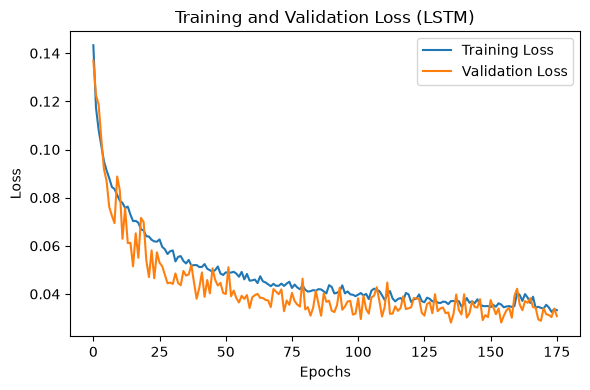

r2_train:   0.8373
r2_test:    0.88682
rmse_train: 2.3083e+05
rmse_test:  1.7908e+05


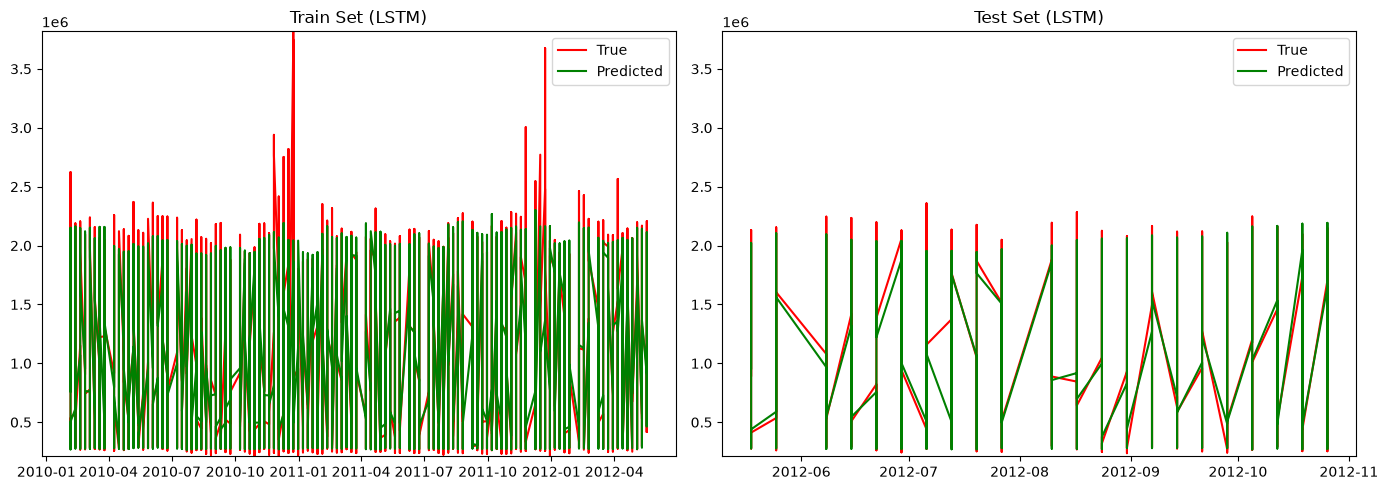

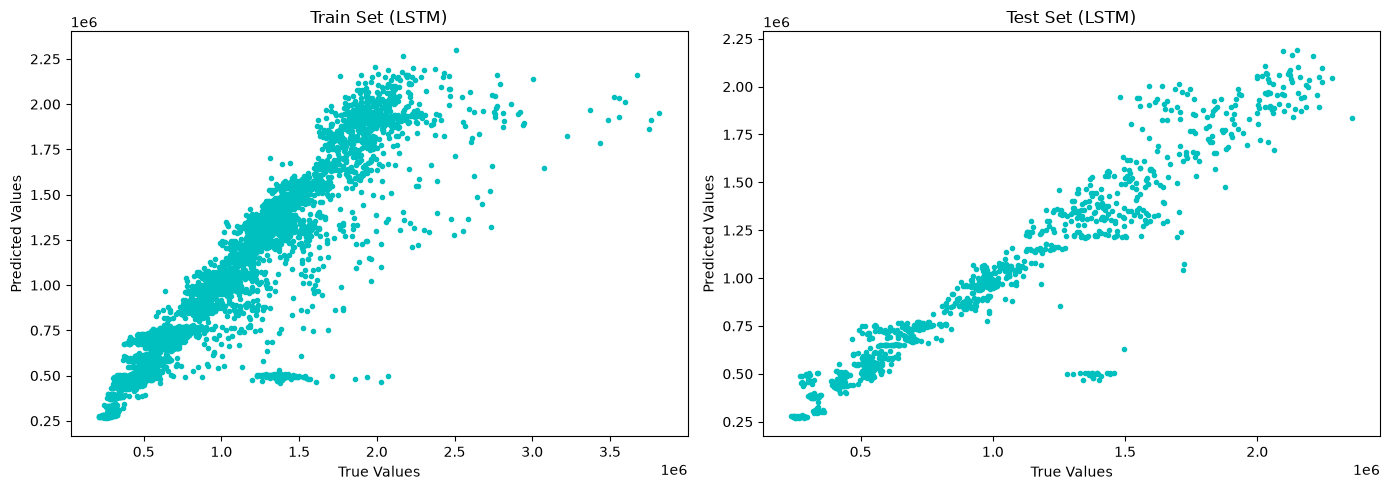

MAE:
  Train: 122034.9389
  Test:  101444.0616
R^2:
  Train: 0.8373
  Test:  0.8868


In [52]:
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import numpy as np

# Re-initialize these variables to ensure they hold the correct data
# X_lstm_sequences_2d, y_lstm_sequences, dates_lstm_sequences are available from cell 5g6G-EnM0UV1
X_for_split = X_lstm_sequences_2d
y_for_split = y_lstm_sequences
dates_for_split = dates_lstm_sequences

n_splits = 5 # Assuming n_splits is 5 as used in previous CV
kf_time_series_reget = TimeSeriesSplit(n_splits=n_splits)

last_train_index = None
last_test_index = None
last_y_train_fold = None
last_y_test_fold = None
last_scaler_y_cv = None

# Iterate through the splits to get the data and scaler for the last fold
for i, (tr_idx, ts_idx) in enumerate(kf_time_series_reget.split(X_for_split)): # Use X_for_split here
    if i == n_splits - 1: # This is the last fold which is fold 5
        last_train_index = tr_idx
        last_test_index = ts_idx
        last_y_train_fold = y_for_split[tr_idx] # Use y_for_split here (numerical target)
        last_y_test_fold = y_for_split[ts_idx]  # Use y_for_split here (numerical target)

        # Recreate scaler_y_cv for the last fold to ensure consistency
        temp_scaler_y_cv = MinMaxScaler(feature_range=(0,1))
        temp_scaler_y_cv.fit(last_y_train_fold.reshape(-1, 1)) # This should now work with numerical data
        last_scaler_y_cv = temp_scaler_y_cv
        break

# NOTE: X_train_scaled_3d_cv, y_train_scaled, X_test_scaled_3d_cv, y_test_scaled
# and history_lstm_final are from the training of the final model in the previous cell (EKLhmJsQ6UOS),
# which used the data from the *last fold* of the cross-validation setup in 4WyL7OHF27oO.
# So, these variables are already aligned with the 'last fold' logic.

y_train_pred_scaled = model_lstm_final.predict(X_train_scaled_3d_cv)
y_test_pred_scaled  = model_lstm_final.predict(X_test_scaled_3d_cv)

# Inverse transform predictions to original scale using the correct scaler_y_cv
y_train_pred = last_scaler_y_cv.inverse_transform(y_train_pred_scaled)
y_test_pred  = last_scaler_y_cv.inverse_transform(y_test_pred_scaled)

# Now use the true values and dates from the last fold's split
y_train_true = last_y_train_fold.reshape(-1, 1)
y_test_true = last_y_test_fold.reshape(-1, 1)
dates_train_plot = dates_for_split[last_train_index] # Use dates_for_split
dates_test_plot = dates_for_split[last_test_index]   # Use dates_for_split

# Create a figure with one subplot for loss
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

# Plot Training and Validation Loss
ax.plot(history_lstm_final.history['loss'], label='Training Loss')
ax.plot(history_lstm_final.history['val_loss'], label='Validation Loss')
ax.set_title('Training and Validation Loss (LSTM)')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.legend()
plt.tight_layout()
plt.show()

# Calculate metrics for LSTM model
r2_train = r2_score(y_train_true, y_train_pred)
print(f'r2_train:   {r2_train:.5}')

r2_test = r2_score(y_test_true, y_test_pred)
print(f'r2_test:    {r2_test:.5}')

rmse_train = mean_squared_error(y_train_true, y_train_pred)**0.5
print(f'rmse_train: {rmse_train:.5}')

rmse_test = mean_squared_error(y_test_true, y_test_pred)**0.5
print(f'rmse_test:  {rmse_test:.5}')

# Convert predictions to pandas Series with dates as index for plotting
y_train_pred_series = pd.Series(y_train_pred.flatten(), index=dates_train_plot)
y_test_pred_series  = pd.Series(y_test_pred.flatten(), index=dates_test_plot)

# Convert dates to datetime objects for proper plotting on x-axis
y_train_pred_series.index = pd.to_datetime(y_train_pred_series.index, format='%d-%m-%Y')
y_test_pred_series.index = pd.to_datetime(y_test_pred_series.index, format='%d-%m-%Y')
dates_train_plot = pd.to_datetime(dates_train_plot, format='%d-%m-%Y')
dates_test_plot = pd.to_datetime(dates_test_plot, format='%d-%m-%Y')

# Calculate global y-axis limits for consistent plotting
y_min = min(y_train_true.min(), y_train_pred_series.min(), y_test_true.min(), y_test_pred_series.min())
y_max = max(y_train_true.max(), y_train_pred_series.max(), y_test_true.max(), y_test_pred_series.max())

# Plot train and test side by side with shared y limits
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(dates_train_plot, y_train_true, 'r', label='True')
axs[0].plot(y_train_pred_series, 'g', label='Predicted')
axs[0].set_title('Train Set (LSTM)')
axs[0].set_ylim(y_min, y_max)
axs[0].legend()

axs[1].plot(dates_test_plot, y_test_true, 'r', label='True')
axs[1].plot(y_test_pred_series, 'g', label='Predicted')
axs[1].set_title('Test Set (LSTM)')
axs[1].set_ylim(y_min, y_max)
axs[1].legend()

plt.tight_layout()
plt.show()

# Plot scatter plots for train and test side by side with shared y limits
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(y_train_true, y_train_pred_series.values, 'c.')
axs[0].set_title('Train Set (LSTM)')
axs[0].set_xlabel('True Values')
axs[0].set_ylabel('Predicted Values')
# axs[0].legend() # Removed as there's no label for scatter plot

axs[1].plot(y_test_true, y_test_pred_series.values, 'c.')
axs[1].set_title('Test Set (LSTM)')
axs[1].set_xlabel('True Values')
axs[1].set_ylabel('Predicted Values')
# axs[1].legend() # Removed as there's no label for scatter plot

plt.tight_layout()
plt.show()

mae_train = mean_absolute_error(y_train_true, y_train_pred)
mae_test = mean_absolute_error(y_test_true, y_test_pred)

print("MAE:")
print(f"  Train: {mae_train:.4f}")
print(f"  Test:  {mae_test:.4f}")
print("R^2:")
print(f"  Train: {r2_train:.4f}")
print(f"  Test:  {r2_test:.4f}")

### Mean Absolute Percentage Error (MAPE) for LSTM

While MAE provides the average absolute error in dollar terms, Mean Absolute Percentage Error (MAPE) offers a more intuitive business metric by expressing this error as a percentage of the actual values. This makes it easier to understand the model's accuracy relative to the scale of sales, regardless of whether sales are in thousands or millions. A lower MAPE indicates a more accurate forecast.

In [53]:
from sklearn.metrics import mean_absolute_percentage_error

mape_test = mean_absolute_percentage_error(y_test_true, y_test_pred)
print(f"LSTM Test MAE (dollar mae): {mae_test:.2f}")
print(f"LSTM Test MAPE (Forecast Accuracy): {mape_test:.4f}")

LSTM Test MAE (dollar mae): 101444.06
LSTM Test MAPE (Forecast Accuracy): 0.1061


In [54]:
import joblib

# Save the LSTM model
model_lstm_final.save('/content/lstm_model.keras')
print("LSTM model saved as 'lstm_model.keras'")

# Save the X scaler
joblib.dump(scaler_X_cv, '/content/scaler_x.joblib')
print("X scaler saved as 'scaler_x.joblib'")

# Save the y scaler
joblib.dump(scaler_y_final, '/content/scaler_y.joblib')
print("Y scaler saved as 'scaler_y.joblib'")

LSTM model saved as 'lstm_model.keras'
X scaler saved as 'scaler_x.joblib'
Y scaler saved as 'scaler_y.joblib'
